# Primer Vistazo

![](images/img1.png)

![](images/img2.png)

![](images/img3.png)

![](images/img4.png)


In [ ]:
import pandas as pd
from unidecode import unidecode
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data_dile.csv')

In [22]:
df = (df.drop_duplicates(subset='text'))

In [27]:
df['text_clean'] = (
    df['text']
    .str.replace(r'@\w+', '', regex=True)        # elimina menciones @
    .str.replace(r'http\S+', '', regex=True)     # elimina URLs que empiezan por http/https
    .str.replace(r'\s+', ' ', regex=True)        # normaliza espacios
    .str.strip()                                 # quita espacios extremos
)



In [28]:

list_of_tweets = []
for text_clean in df['text_clean']:
    complete_clean = unidecode(text_clean.lower())
    list_of_tweets.append(complete_clean)

In [141]:
stop_words = set()
stop_words.update([
    'a', 'de', 'https', 'http', 'y', 'e', 'el', 'den', 'por', 'ni', 'eso', 'que', 'con', 've', '1', 'lo', 'la', 'los', 'estan', 'no', 'le', 'se'
     ,'es', 'como','su', 'va', 'del','en', 'esta', 'ya', 'van', 'todo', 'para', 'mas', 'les', 'esto', 'sus', 'sin','o', 'ese', 'ahora', 'pero',
     'ello', 'porque', 'un', 'si', 'al', 'que', 'las', 'q', 'ellos', 'ahi', 'era','nada', 'nos', 'una', 'este', 'solo'])

In [142]:
text_all = " ".join(list_of_tweets)
from wordcloud import WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stop_words,
    collocations=False,   # evita palabras pegadas
    max_words=200
).generate(text_all)


## Nube de palabras

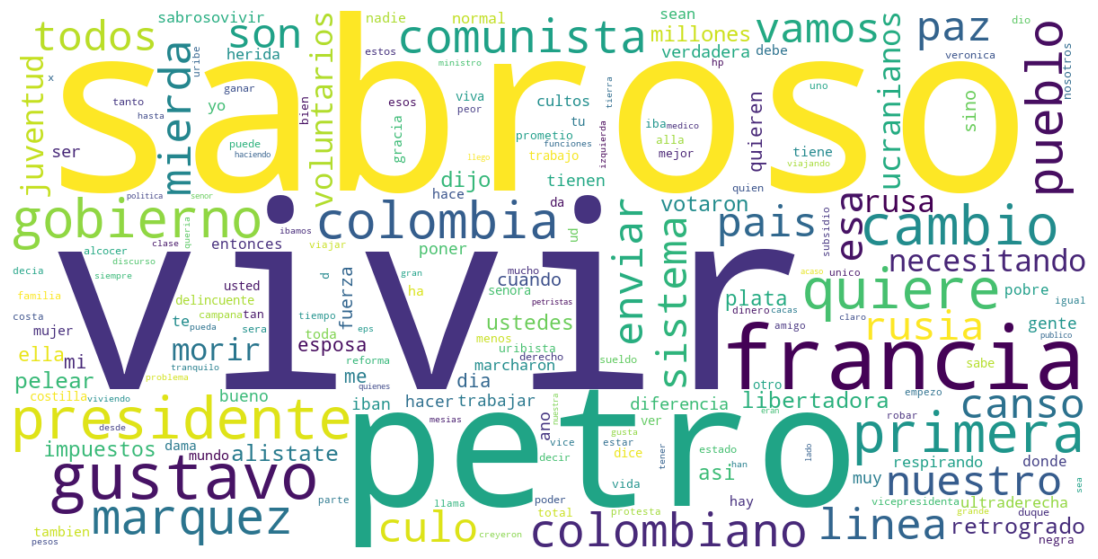

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [145]:
malas_palabras = [
    # Ideológicas / descalificación política
    "comunista",
    "ultraderecha",
    "retrogrado",
    "delincuente",
    "corrupto",

    # Emocionales / valorativas
    "cansó",
    "mierda",
    "culo",
    #"pobre",
    "solo",

    # Conflicto / violencia
    #"guerra",
    #"pelear",
    #"morir",
    #"herida",
    "rusia",

    # Socioeconómicas (en tono crítico)
    "impuestos",
    "plata",
    "necesitando",
    "millones"
]


In [147]:
words = re.findall(r'\b[a-záéíóúñü]+\b', text_all)

In [ ]:
words = [w for w in words if w not in stop_words]
word_freq = Counter(words)

In [ ]:

df_words = (
    pd.DataFrame(word_freq.items(), columns=['word', 'count'])
      .sort_values('count', ascending=False)
      .head(20)
)

## Conteo por Barras

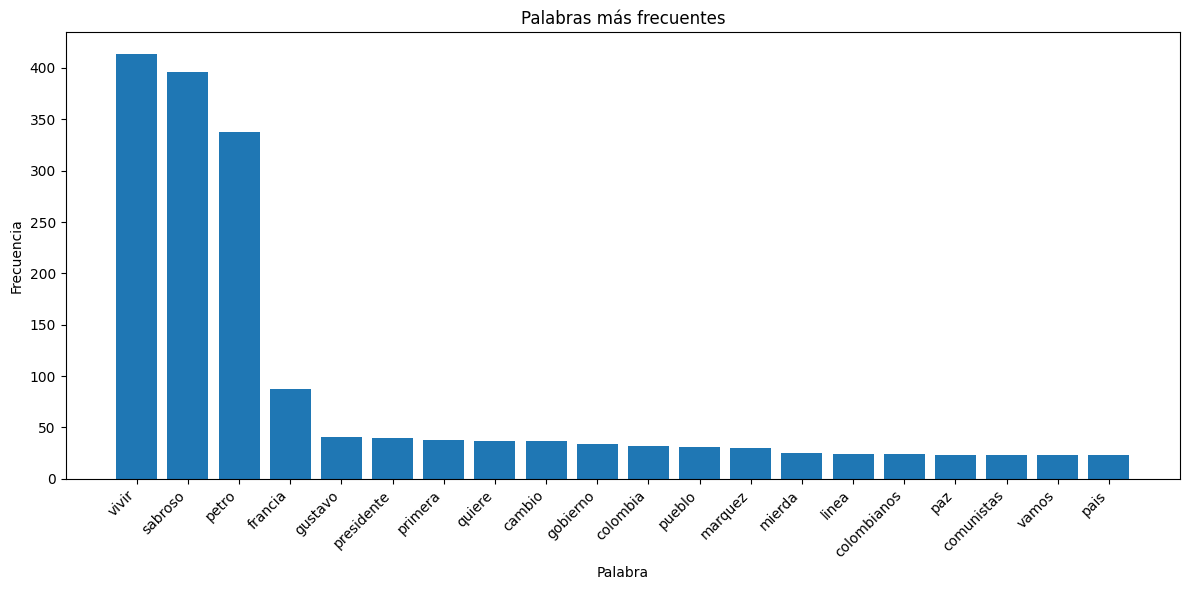

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(df_words['word'], df_words['count'])
plt.xticks(rotation=45, ha='right')
plt.title("Palabras más frecuentes")
plt.ylabel("Frecuencia")
plt.xlabel("Palabra")
plt.tight_layout()
plt.show()
